# Experiments with fitting wavelet coefficients marginal distributions 

In [15]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage
import math 

import sys
from pathlib import Path

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from check_moments import *
from check_potentials import * 
from paper_figures import * 
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


## Data preprocessing

In [7]:
# Orthogonal wavelet
W = DefineWavelet('Db', m=3, device=device)

Data = load_turbulence_1d()
print(Data.shape) 

n1 = 512
Data = split_periodize_reshape(Data, n1)

print(Data.shape) 

for j in range(1):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:10000]).to(device) # choose here if you want less data 
print('Data shape after preprocessing:', Data.shape)
print('x1 shape:', x1.shape) 

n1, channels, M = x1.shape
print(f'(B, C, T) = ({n1}, {channels}, {M}).')
J = 8
Q = 3

torch.Size([10000, 1, 1800])
torch.Size([30000, 1, 512])
Data shape after preprocessing: torch.Size([30000, 1, 256])
x1 shape: torch.Size([10000, 1, 256])
(B, C, T) = (10000, 1, 256).


### Verify data qualitatively

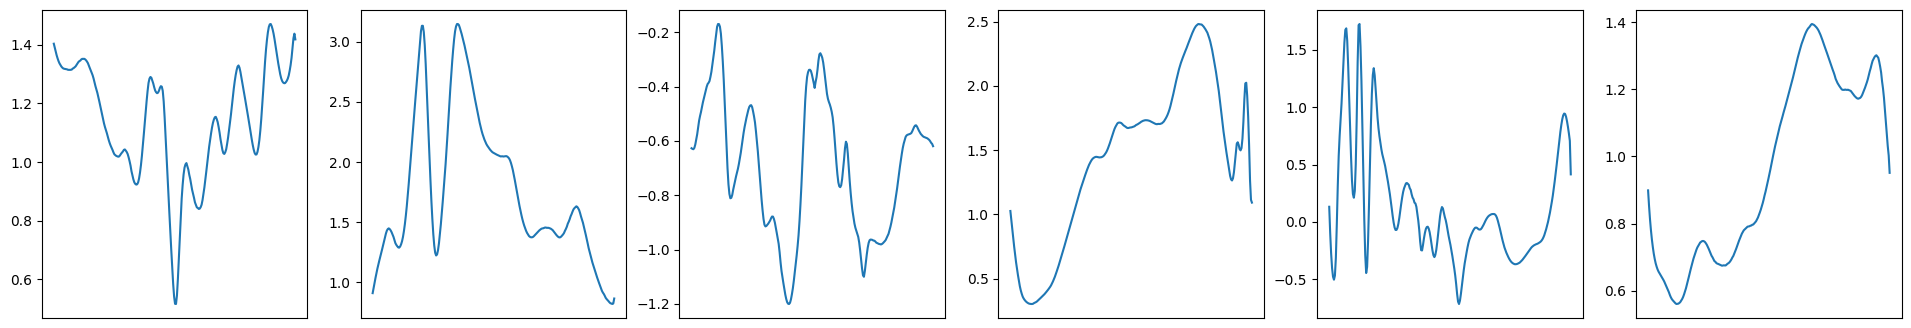

In [8]:
%matplotlib inline 
plot_time_series_row(x1, 6)

## Interactively investigate wavelet coefficients histograms: lin/log scale 

In [9]:
from ipywidgets import FloatSlider, IntSlider, ToggleButtons, interact

def analyze_wavelets(wt):
    """Creates an interactive widget to analyze wavelet coefficient histograms.

    Args:
        wt (torch.Tensor): Wavelet coefficients tensor of shape (B, J, T)
    """
    n_wavelets = wt.shape[1]

    # Pre-extract and flatten numpy arrays for speed during widget updates
    wavelet_data = []
    for i in range(n_wavelets):
        vals = wt[:, i, :].detach().cpu().flatten().numpy()
        wavelet_data.append(vals)

    # Define the interactive plotting function
    def update_plot(ch, x_min, x_max, percentile, scale):
        vals = wavelet_data[ch]

        # Calculate metrics based on current parameters
        total_counts = len(vals)
        counts_in_support = np.sum((vals >= x_min) & (vals <= x_max))
        pct_in_support = (counts_in_support / total_counts) * 100

        # Calculate percentile value (e.g., 95th percentile of absolute values or raw values)
        # Using absolute values is often helpful for symmetric wavelet coefficients
        pct_val_pos = np.percentile(vals, percentile)
        pct_val_neg = np.percentile(vals, 100 - percentile)

        # ------------------------------------------------------------------
        # Plotting
        # ------------------------------------------------------------------
        fig, ax = plt.subplots(figsize=(10, 5))

        # Plot histogram, log or linear depending on the `scale` toggle
        counts, bins, patches = ax.hist(
            vals, bins=100, density=True, log=(scale == "log"), alpha=0.6, color="skyblue"
        )

        # Highlight the selected support region
        ax.axvspan(x_min, x_max, color="green", alpha=0.15, label="Selected Support")

        # Vertical lines for percentiles
        ax.axvline(
            pct_val_pos,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label=f"{percentile}th Pct ({pct_val_pos:.4f})",
        )
        ax.axvline(
            pct_val_neg,
            color="orange",
            linestyle="--",
            linewidth=1.5,
            label=f"{100-percentile}th Pct ({pct_val_neg:.4f})",
        )

        # Formatting
        ax.set_title(f"Analysis | Channel {ch}", fontsize=14)
        ax.set_xlabel("Coefficient Value")
        ax.set_ylabel(f"Density ({scale.capitalize()} Scale)")
        ax.legend(loc="upper right")
        ax.grid(True, which="both", linestyle=":", alpha=0.5)

        plt.show()

        # ------------------------------------------------------------------
        # Print Summary Stats
        # ------------------------------------------------------------------
        print(f"--- Channel {ch} Analysis ---")
        print(
            f"Support [{x_min:.3f}, {x_max:.3f}]: {counts_in_support:,} / {total_counts:,} samples ({pct_in_support:.2f}%)"
        )
        print(f"{percentile}th Percentile Value: {pct_val_pos:.6f}")
        print(f"{100-percentile}th Percentile Value: {pct_val_neg:.6f}")

    # Set up slider ranges based on global min/max of the data to keep it intuitive
    all_min = float(np.min([np.min(w) for w in wavelet_data]))
    all_max = float(np.max([np.max(w) for w in wavelet_data]))
    # Round slightly outward for clean slider steps
    step = (all_max - all_min) / 200

    # Trigger the interactive dashboard
    interact(
        update_plot,
        ch=IntSlider(min=0, max=n_wavelets - 1, step=1, value=6, description="Channel"),
        x_min=FloatSlider(
            min=all_min, max=all_max, step=step, value=all_min, description="X Min"
        ),
        x_max=FloatSlider(
            min=all_min, max=all_max, step=step, value=all_max, description="X Max"
        ),
        percentile=FloatSlider(
            min=95.0, max=100.0, step=0.005, value=95.0, description="Percentile"
        ),
        scale=ToggleButtons(options=["log", "linear"], value="log", description="Y Scale"),
    )


# ------------------------------------------------------------------
# To run it, just pass your `wt` tensor:
# ------------------------------------------------------------------
filters = return_Filters(M, J, 1, device=device)
wt = torch.fft.ifft(torch.fft.fft(x1) * filters).real  # (B, J, T)
analyze_wavelets(wt)

interactive(children=(IntSlider(value=6, description='Channel', max=8), FloatSlider(value=-3.551537275314331, …

## Fitting wavelet coefficients histograms with Generalized Gaussian windows model  

### Q = 1 

    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-28329142  K2=-28500279  K3=-28519326  K4=-28521848)
[GGD^4][ch 0] Keff=4  cuts=[0.0005 0.0017 0.0124]  pi=[59.2% 30.4% 9.8% 0.5%]  alpha=[1.58 0.38 0.40 0.43]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-25323947  K2=-25446304  K3=-25463739  K4=-25465500)
[GGD^4][ch 1] Keff=4  cuts=[0.0003 0.0034 0.0267]  pi=[31.9% 57.5% 10.1% 0.5%]  alpha=[1.70 0.44 0.40 0.44]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-18702128  K2=-18782042  K3=-18791182  K4=-18791928)
[GGD^4][ch 2] Keff=4  cuts=[0.0018 0.0126 0.0842]  pi=[45.5% 43.8% 10.2% 0.5%]  alpha=[1.20 0.37 0.40 0.49]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-12498946  K2=-12542473  K3=-12542575  K4=-12542931)
[GGD^4][ch 3] Keff=4  cuts=[0.0030 0.0415 0.1019]  pi=[25.1% 64.4% 8.1% 2.4%]  alpha=[1.39 0.52 0.42 0.67]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-8016256  K2=-8027646  K3=-8027801  K4=-8028227)
[GGD^4][ch 4] Keff=4  cu

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence/../codes/potentials/potentials_1d.py:1166: RuntimeWarning: overflow encountered in cast
  logpdf = (np.log(a) - np.log(2.0) - np.log(s) - gammaln(1.0 / a) - (ah / s) ** a)


    [model-select] chose K=4  (Kmax=4)  (BIC: K1=6750540  K2=6744720  K3=6743004  K4=6740519)
[GGD^4][ch 8] Keff=4  cuts=[0.2784 0.5004 1.1728]  pi=[25.6% 17.1% 37.6% 19.7%]  alpha=[3.41 8.00 1.53 2.44]  active=4
[active] 34 active statistics (2 dead slots dropped before they can singularize the Gram)
[prune-diagnostic] R-diagonal ratios (sorted desc), first 10 / last 10:
  head=[1.     1.     1.     1.     0.9999 0.9999 0.9999 0.9998 0.9995 0.9994]
  tail=[0.89770995 0.88285586 0.87813375 0.850637   0.82464451 0.80437168
 0.69334008 0.49577625 0.46137643 0.23839141]
[prune] dropped 0 near-collinear statistic(s); 34 remain


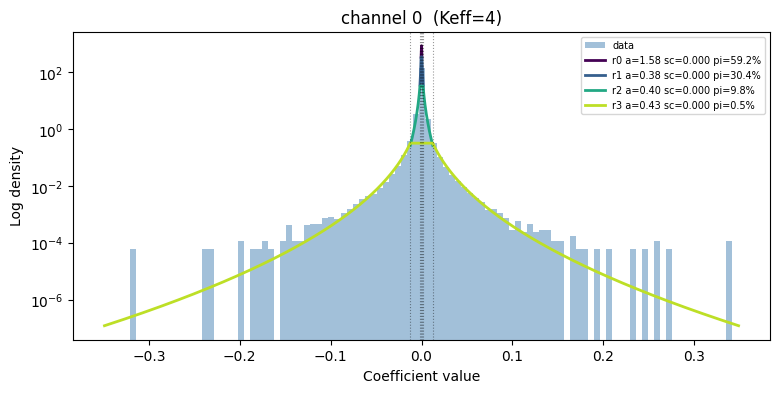

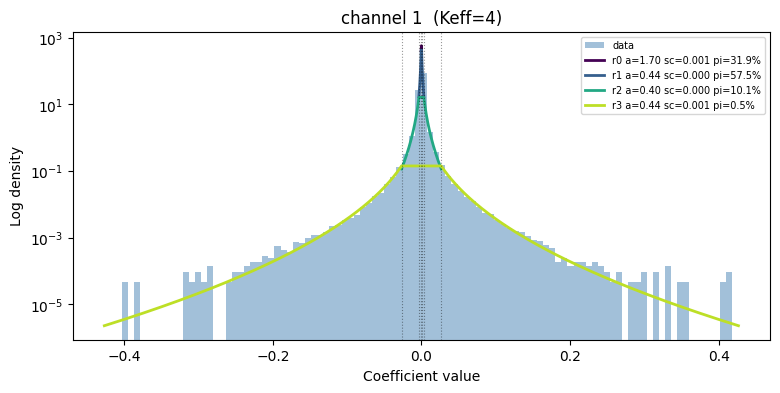

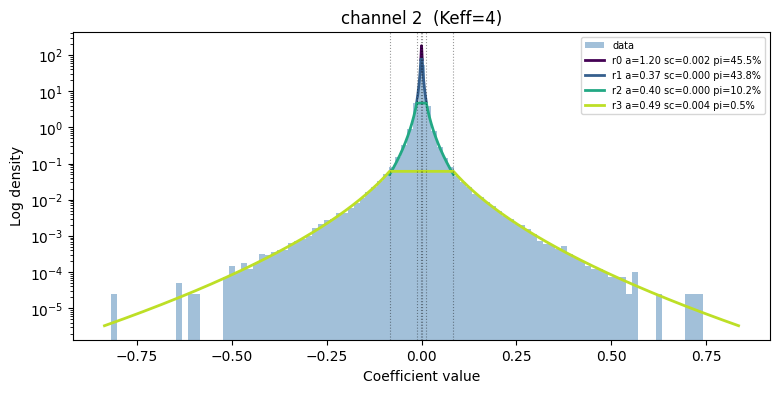

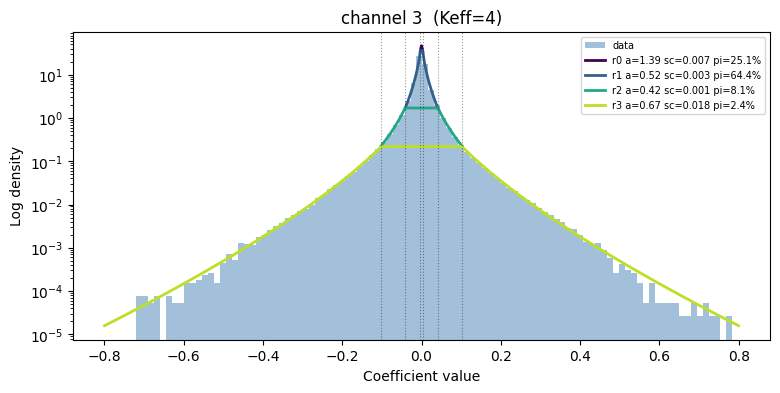

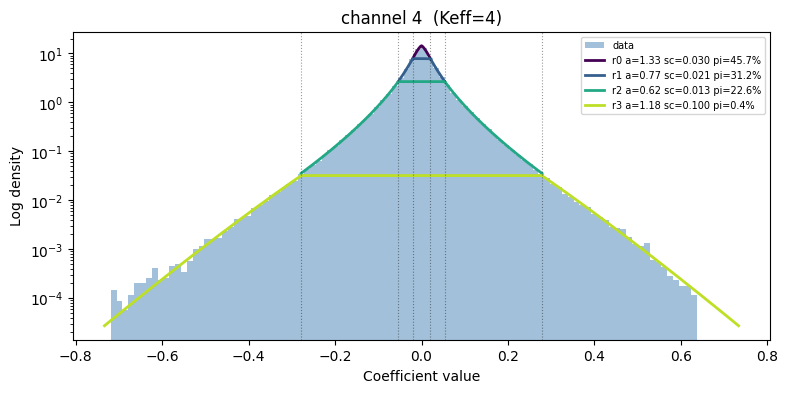

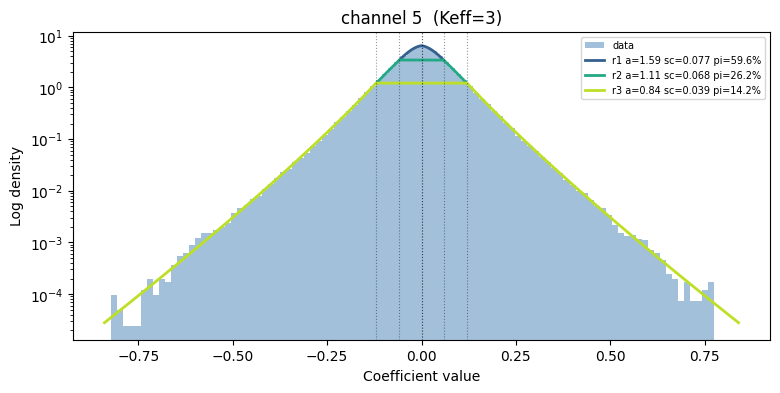

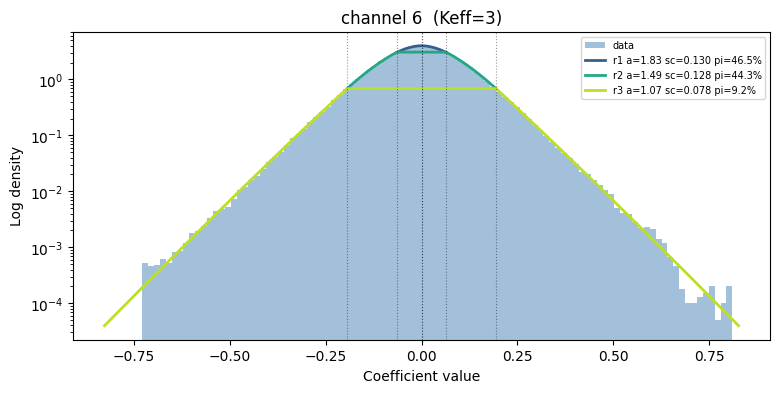

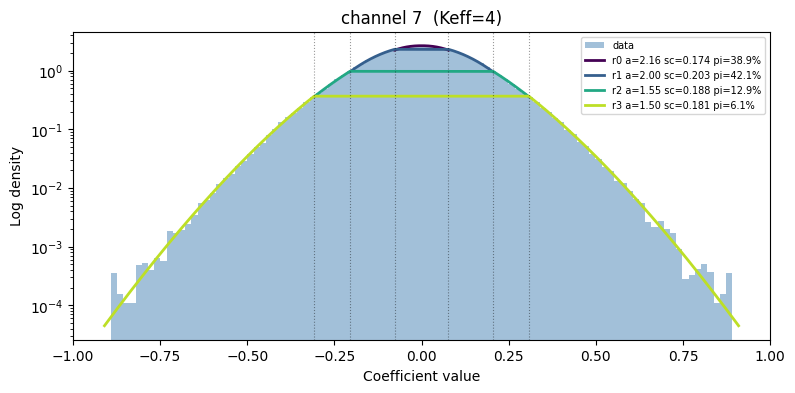

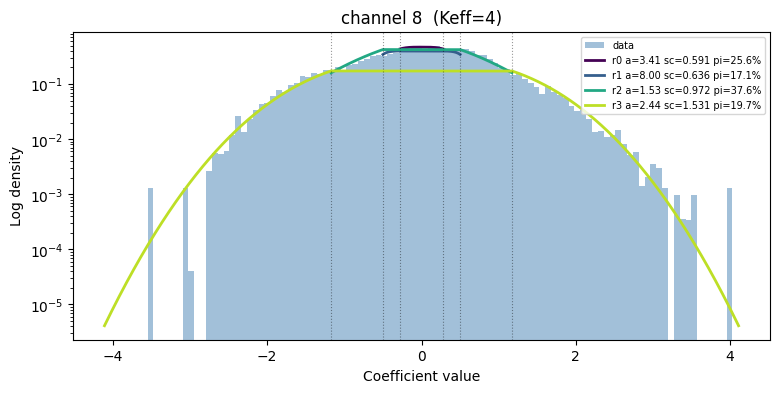

In [10]:
filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
model = Scalar_GGD_KRegion(filters)
model.fit_reference(x1)

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence/../codes/check_potentials.py:1714: RuntimeWarning: overflow encountered in exp
  g = [1.0 / (1.0 + np.exp(-(C[j, m] - az) / SW[j, m]))


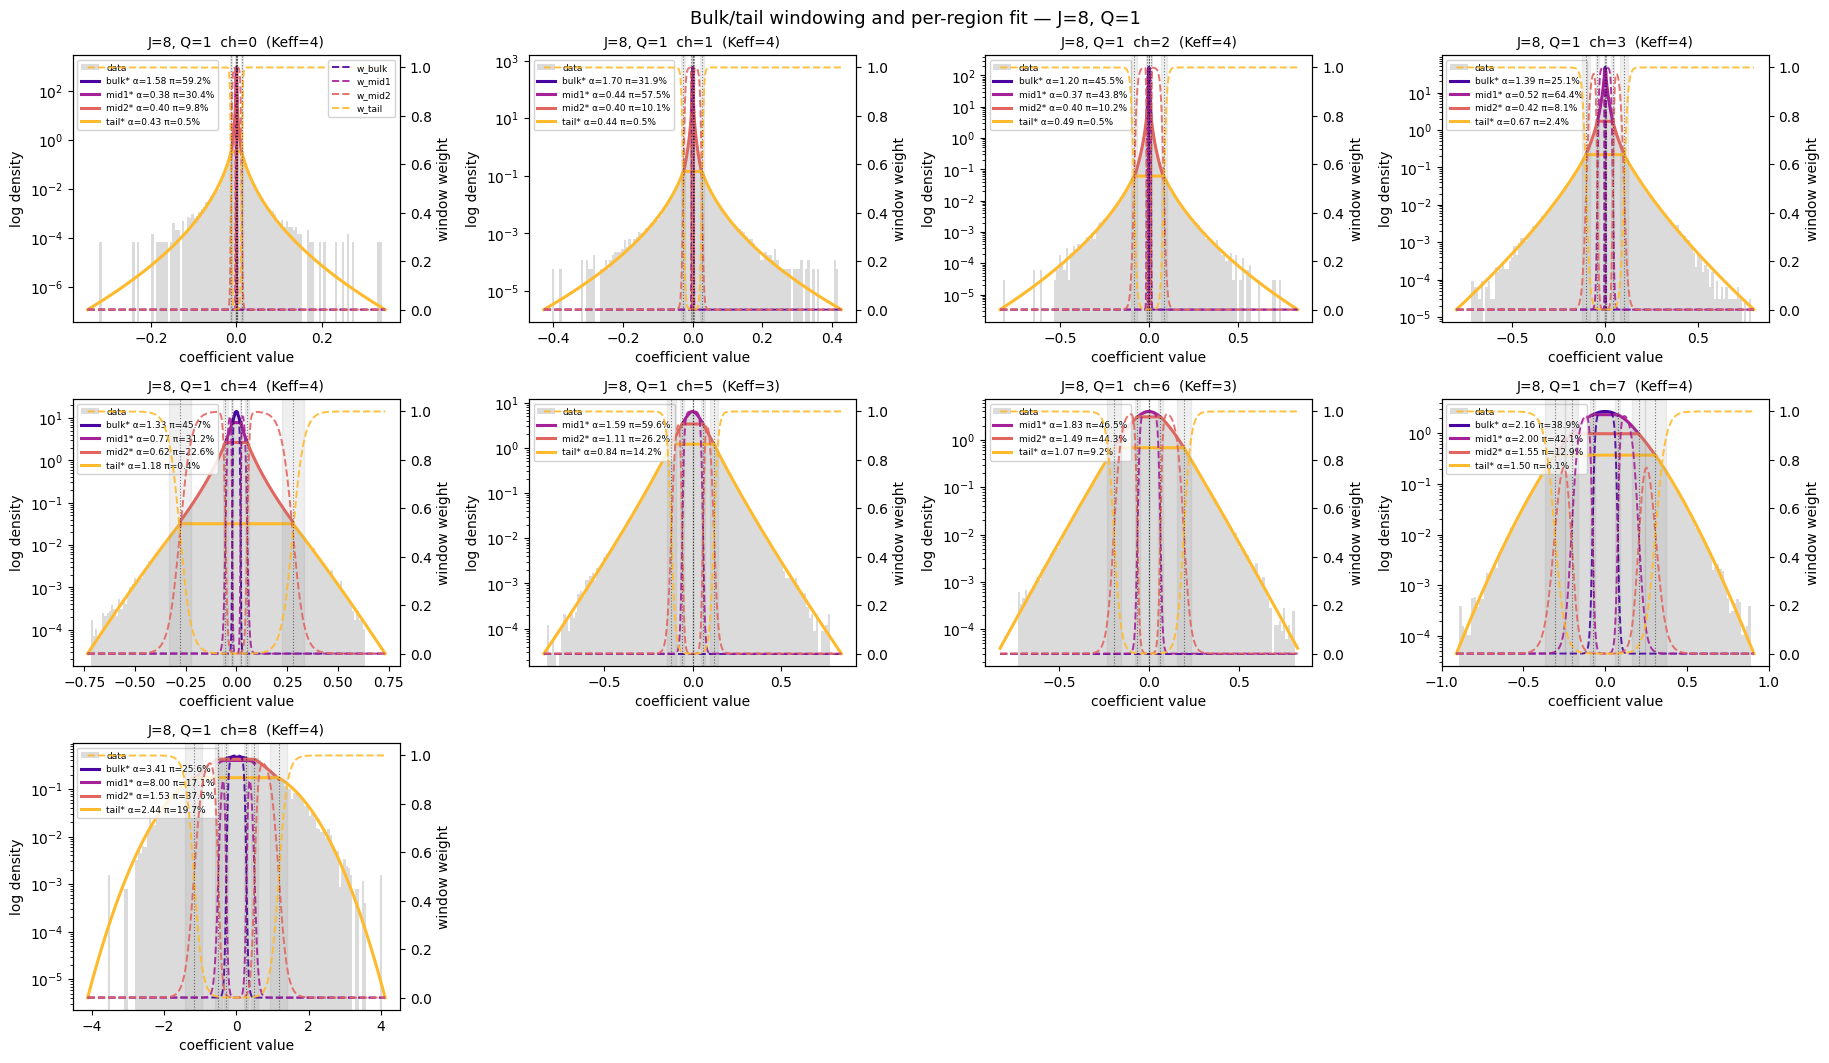

In [13]:
plot_kregion_fit_with_windows(x1, model, label="J=8, Q=1")

In [25]:
def plot_kregion_fit_paper(x, model, channel, label="", n_grid=800,
                            figsize=(9, 8), fontsize=15):
    """
    Single-channel, publication-ready figure for Scalar_GGD_KRegion.

    Two stacked panels sharing the x-axis (coefficient value):
      - top:    the smooth partition-of-unity windows w_k(z) that blend
                the K regions (bulk -> mid -> ... -> tail)
      - bottom: empirical histogram of the wavelet coefficients (log
                density) with the fitted truncated-GGD density overlaid
                per region, colored to match the window it corresponds to

    Does not refit -- uses model.alpha/scale/cuts/sw/pi/active as already
    fitted by model.fit_reference(...).
    """
    model._check_fitted()
    j = channel

    filters = model.filters.to(x.device)
    wt = torch.fft.ifft(torch.fft.fft(x) * filters).real

    A = model.alpha.cpu().numpy();  S = model.scale.cpu().numpy()
    C = model.cuts.cpu().numpy();   SW = model.sw.cpu().numpy()
    P = model.pi.cpu().numpy();     ACT = model.active.cpu().numpy()
    Keff = model.Keff.cpu().numpy()
    K = A.shape[1]

    h = wt[:, j, :].detach().cpu().flatten().numpy()
    h = h[np.isfinite(h)]
    ah = np.abs(h)
    xmax = float(ah.max()) * 1.02
    edges = [0.0] + list(C[j]) + [xmax]

    region_colors = plt.cm.plasma(np.linspace(0.12, 0.85, K))
    region_names = (["bulk"] + [f"mid_{{{k}}}" for k in range(1, K - 1)]
                     + (["tail"] if K > 1 else []))

    fig, (ax_w, ax_d) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw=dict(height_ratios=[1, 2.4], hspace=0.06))

    # ------------------------------------------------------------------
    # top panel: windows w_k(z)
    # ------------------------------------------------------------------
    zg = np.linspace(-xmax, xmax, 1000)
    az = np.abs(zg)
    if K == 1:
        ws = [np.ones_like(az)]
    else:
        g = [1.0 / (1.0 + np.exp(-(C[j, m] - az) / SW[j, m])) for m in range(K - 1)]
        ws = [g[0]]
        for m in range(1, K - 1):
            ws.append(g[m] - g[m - 1])
        ws.append(1.0 - g[K - 2])

    for k in range(K):
        name = region_names[k] if k < len(region_names) else f"r_{{{k}}}"
        ax_w.plot(zg, ws[k], lw=2.6, color=region_colors[k],
                  label=rf"$w_{{{name}}}$")

    for c_m, s_m in zip(C[j], SW[j]):
        for sign in (-1, 1):
            ax_w.axvline(sign * c_m, color="k", ls=":", lw=1.0, alpha=0.6)
            ax_d.axvline(sign * c_m, color="k", ls=":", lw=1.0, alpha=0.5)
            ax_w.axvspan(sign * c_m - 2 * s_m, sign * c_m + 2 * s_m,
                         color="gray", alpha=0.12)
            ax_d.axvspan(sign * c_m - 2 * s_m, sign * c_m + 2 * s_m,
                         color="gray", alpha=0.12)

    ax_w.set_ylim(-0.05, 1.08)
    ax_w.set_ylabel("window\nweight", fontsize=fontsize)
    ax_w.legend(fontsize=fontsize - 3, ncol=K, loc="upper center",
                bbox_to_anchor=(0.5, 1.35), frameon=False)
    ax_w.tick_params(labelsize=fontsize - 2)

    # ------------------------------------------------------------------
    # bottom panel: data histogram + fitted densities
    # ------------------------------------------------------------------
    ax_d.hist(h, bins=120, density=True, log=True, alpha=0.35,
              color="0.55", label="data", zorder=1)

    for k in range(K):
        if P[j, k] < 1e-4:
            continue
        lo, hi = edges[k], edges[k + 1]
        hi_fit = np.inf if k == K - 1 else hi
        xp = np.linspace(max(lo, 1e-6), hi, n_grid)
        lp = model._logpdf_trunc(xp, A[j, k], S[j, k], lo, hi_fit, P[j, k])
        xx = np.concatenate([-xp[::-1], xp])
        yy = np.exp(np.concatenate([lp[::-1], lp]))
        name = region_names[k] if k < len(region_names) else f"r_{{{k}}}"
        star = r"$^{*}$" if ACT[j, k] else ""
        ax_d.plot(xx, yy, lw=3, color=region_colors[k], zorder=3,
                  label=rf"${name}${star}: $\alpha$={A[j,k]:.2f}, $\pi$={P[j,k]:.1%}")

    ax_d.set_xlabel("coefficient value $x$", fontsize=fontsize)
    ax_d.set_ylabel("log density", fontsize=fontsize)
    ax_d.legend(fontsize=fontsize - 3, loc="upper right", framealpha=0.9)
    ax_d.tick_params(labelsize=fontsize - 2)

    fig.suptitle(f"{label}  —  channel {j}  ($K_{{eff}}$={int(Keff[j])})",
                 fontsize=fontsize + 2, y=1.0)
    y_thresh = 5e-5
    ax_d.set_ylim(bottom=y_thresh)
    plt.tight_layout()
    plt.savefig(f"fitting_Q3_marginal_channel{channel}.png")
    return fig

/tmp/xpython_1833004/1597256829.py:50: RuntimeWarning: overflow encountered in exp
  g = [1.0 / (1.0 + np.exp(-(C[j, m] - az) / SW[j, m])) for m in range(K - 1)]
/tmp/xpython_1833004/1597256829.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


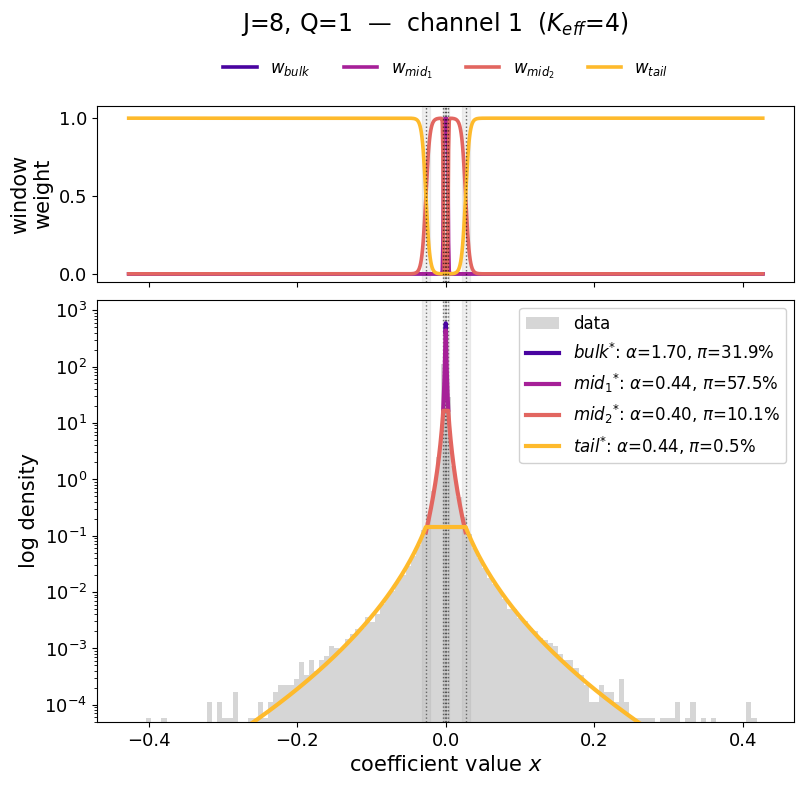

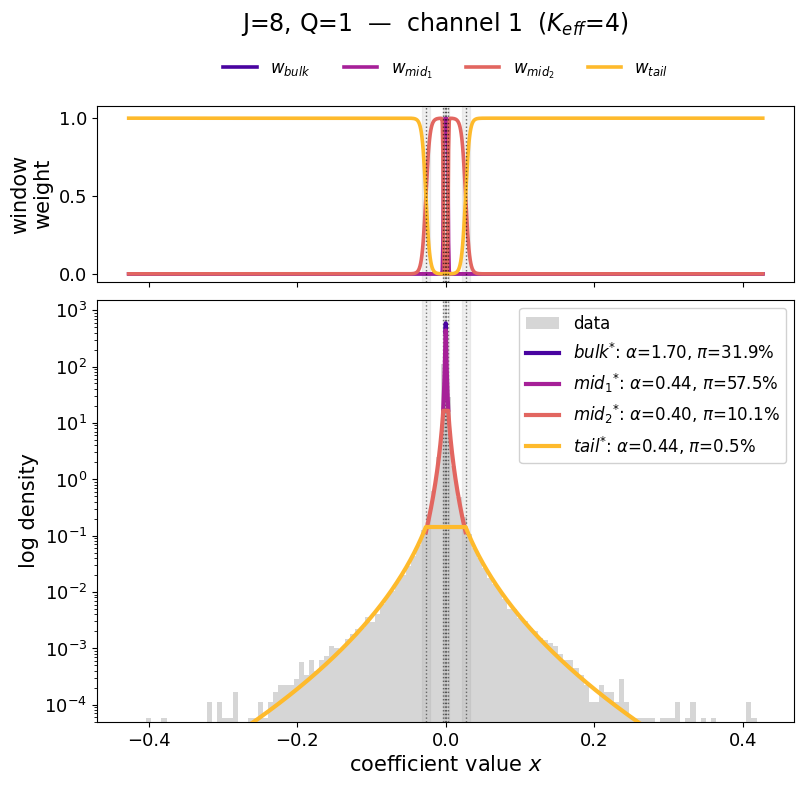

In [26]:
# choose one plot for the paper 
plot_kregion_fit_paper(x1, model, channel=1, label="J=8, Q=1")

### Q = 3

In [ ]:
filtersQ3 = return_Filters(M, J, 3, device=device)
modelQ3 = Scalar_GGD_KRegion(filtersQ3)
modelQ3.fit_reference(x1)

In [ ]:
plot_kregion_fit_with_windows(x1, modelQ3, label="J=8, Q=3")

In [ ]:
# choose one plot for the paper 
plot_kregion_fit_paper(x1, modelQ3, channel = 16, label="J=8, Q=3")

## Derive analytical shape of fit, compare generated and original data 

In [ ]:
for m, label in [(model, "Q=1"), (modelQ3, "Q=3")]:
    n_ch = m.filters.shape[1]
    ncols = 4
    nrows = math.ceil(n_ch / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()
    for i in range(n_ch):
        m.compare_channel(x1, j=i, ax=axes[i])
    for j in range(n_ch, len(axes)):
        axes[j].axis("off")
    plt.suptitle(f"{label}: fit vs generated vs analytic shape", fontsize=20)
    plt.tight_layout()
    plt.show()

## Compare real and imaginary part of wavelet coefficient plots 

In [ ]:
def plot_wavelet_real_imag(x1: torch.Tensor, filters: torch.Tensor,
                      label: str = "Wavelet",
                     fit_coshgt: bool = True) -> None:
    
    # 1. Ensure x1 has a singleton dimension for broadcasting over filters
    # If x1 is (B, T), unsqueeze(1) makes it (B, 1, T) so it broadcasts over (1, J, T) filters
    x1_fft = torch.fft.fft(x1.unsqueeze(1) if x1.ndim == 2 else x1)
    
    # 2. Perform the frequency-domain multiplication and IFFT
    wt_complex = torch.fft.ifft(x1_fft * filters)
    wt_imag = wt_complex.imag  # (B, J, T)
    wt_real = wt_complex.real  # (B, J, T)
    
    n_wavelets = filters.shape[1]
    
    # ------------------------------------------------------------------
    # 1. Overview grid
    # ------------------------------------------------------------------
    ncols = 5
    nrows = math.ceil(n_wavelets / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    
    # Handle edge case where n_wavelets = 1 (axes wouldn't be an array)
    if n_wavelets == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i in range(n_wavelets):
        # .numpy() works smoothly if detached and moved to CPU
        vals_imag = wt_imag[:, i, :].detach().cpu().numpy().flatten()
        vals_real = wt_real[:, i, :].detach().cpu().numpy().flatten()
    
        axes[i].hist(vals_imag, bins=50, density=True, log=True, alpha=0.5, label="Imag")
        axes[i].hist(vals_real, bins=50, density=True, log=True, alpha=0.5, label="Real")
        axes[i].set_title(f"{label} ch={i}")
        axes[i].set_xlabel("Coefficient value")
        axes[i].set_ylabel("Density")
        if i == 0:
            axes[i].legend()  # Add a legend to the first plot for clarity
    
    # Hide unused subplots
    for j in range(n_wavelets, len(axes)):
        axes[j].axis("off")
    
    plt.suptitle(f"Wavelet coefficient histograms — {label}", fontsize=13)
    plt.tight_layout()
    
    # 3. If this code is inside a loop, use plt.draw() or plt.pause() instead, 
    # or clear the figure afterward so the next loop can plot.
    plt.show()

In [ ]:
filters = return_Filters(M, J, 1, device=device)
plot_wavelet_real_imag(x1, filters, label="Q=1") 
filters_Q = return_Filters(M, J, 3, device=device)
plot_wavelet_real_imag(x1, filters_Q, label="Q=3") 
